In [89]:
import importlib

from mysklearn.mypytable import MyPyTable 
import mysklearn.myutils
importlib.reload(mysklearn.myutils)

from mysklearn import myutils
from mysklearn.myclassifiers import MySimpleLinearRegressionClassifier
from mysklearn.myclassifiers import MyKNeighborsClassifier
from mysklearn.myclassifiers import MyNaiveBayesClassifier
from mysklearn.myclassifiers import MyDecisionTreeClassifier
from mysklearn.myclassifiers import MyDummyClassifier
from mysklearn.myclassifiers import MyRandomForestsClassifier
import mysklearn.myevaluation as myEval


alphabet_teams = ['Atlanta Hawks', 'Boston Celtics', 'Brooklyn Nets', 'Charlotte Hornets', 'Chicago Bulls',
        'Cleveland Cavaliers', 'Dallas Mavericks', 'Denver Nuggets', 'Detroit Pistons', 'Golden State Warriors', 'Houston Rockets', 'Indiana Pacers',
        'Los Angeles Clippers', 'Los Angeles Lakers', 'Memphis Grizzlies', 'Miami Heat', 'Milwaukee Bucks', 'Minnesota Timberwolves',
        'New Orleans Pelicans', 'New York Knicks', 'Oklahoma City Thunder', 'Orlando Magic', 'Philadelphia 76ers',
        'Phoenix Suns', 'Portland Trailblazers', 'Sacramento Kings', 'San Antonio Spurs', 'Toronto Raptors', 'Utah Jazz', 'Washington Wizards']


# Project Report
#### By: Joe Mock and James Cross

<p>In this project, we decided to look at data concerning the National Basketball Association (NBA). All data used in this project was provided by basketball-reference.com. <br>For some context, every team in the NBA plays 82 games in what is called the "Regular Season." Based on win/loss ratios in these games and a few other factors, teams will be ranked and play in "Playoff" games, where they will be put into a bracket and compete to win the championship.<br><br>We will primarily look at win/loss ratios to attempt to predict whether or not teams will make it to the playoffs through their first 10-20 games. All data that we will be using is from the 2024-25 NBA season to ensure current stats that can be used for training and testing on future NBA seasons.<br><br>We will train our classifier on averages through an entire season for every season played by every team in the NBA, and test against that same data for whether those teams in those seasons made the playoffs. At the end we will see what our classifier says about this season, and we can test again when the playoffs occur in April, as the current NBA season is only about a month in.</p>

## Data Cleaning and Analysis

<p>Basketball Reference does not provide a holistic view for the data that we wish to look at, so we will have to look at two different files to clean and join for relevant data. By creating a unique id column in each file, we can join each season as it correlates to itself. Each file was compiled in the same way but just for different stats (each row in each file correlates to the same row in the other file where each row corresponds to a specific season played by a specific team in the NBA).</p>

In [83]:
# We will first load our datasets from .txt files pulled from basketball-reference.com
# This includes data for every season played by every team in the NBA
nba_data = MyPyTable().load_from_file("data/input/season_data.txt")
nba_stats = MyPyTable().load_from_file("data/input/season_stats.txt")
nba_data.drop_column(['Team','W','L','W/L%','Finish','SRS','','Pace','Rel Pace','Rel ORtg','Rel DRtg','Coaches','Top WS'])
nba_stats.drop_column([''])
nba_data.add_keyid_column()
nba_stats.add_keyid_column()
nba_all_data = nba_data.perform_full_outer_join(nba_stats, ["id", "Season", "Lg"])
myutils.label_playoff(nba_all_data)
nba_all_data.remove_rows_with_missing_values()

nba_all_data.save_to_file("data/output/trial1.txt")

## Data Visualization

Text(0, 0.5, 'Number of teams')

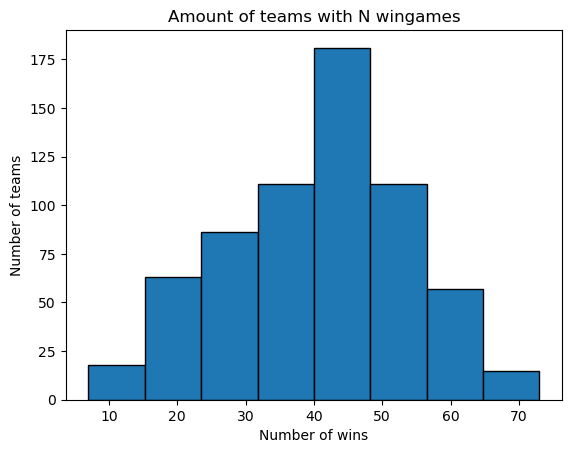

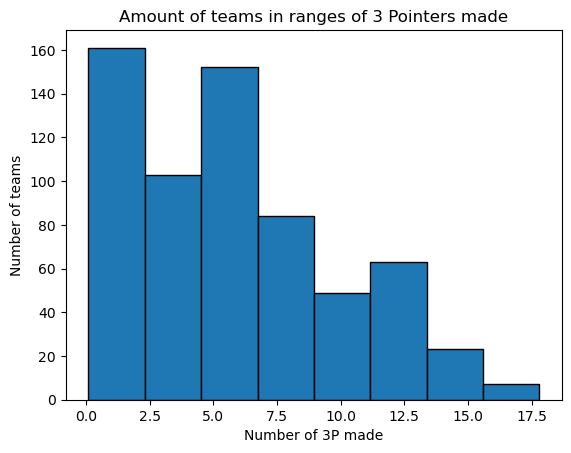

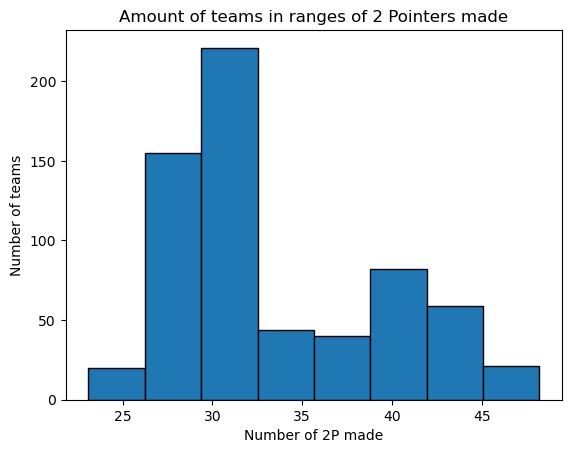

In [84]:
# TODO : Plug in code for visualizing data - Histograms

# Things to consider: Win/Loss, Points, FG%
plt.figure()
xs = nba_all_data.get_column("W")
plt.hist(xs, bins=8, edgecolor='black')
plt.title(f"Amount of teams with N wingames")
plt.xlabel("Number of wins")
plt.ylabel("Number of teams")

plt.figure()
xs = nba_all_data.get_column("3P")
plt.hist(xs, bins=8, edgecolor='black')
plt.title("Amount of teams in ranges of 3 Pointers made")
plt.xlabel("Number of 3P made")
plt.ylabel("Number of teams")

plt.figure()
xs = nba_all_data.get_column("2P")
plt.hist(xs, bins=8, edgecolor='black')
plt.title("Amount of teams in ranges of 2 Pointers made")
plt.xlabel("Number of 2P made")
plt.ylabel("Number of teams")


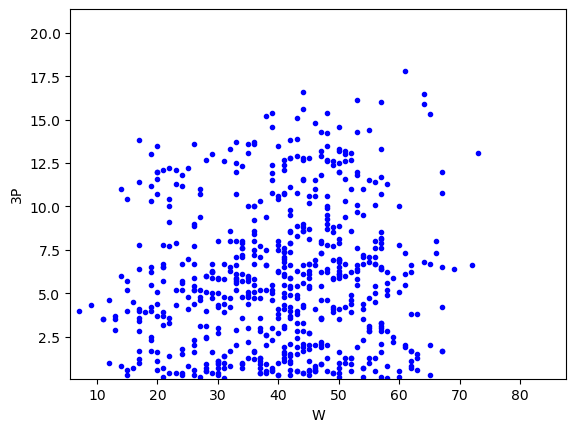

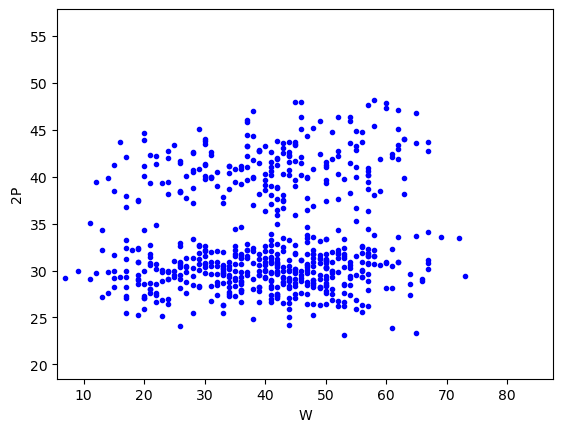

In [85]:
# TODO : Plug in code for visualizing data - Scatterplots
myutils.get_scatter("W", "3P", nba_all_data)
myutils.get_scatter("W", "2P", nba_all_data)


With these scatterplots and box plots, we can make some assertations about the data and talk about it a little bit. Like what does it mean and what it can help to exemplify within out project.

## Classifier Training

<p>Now that we have all data loaded and cleaned, we can continue by building, training, and evaluating the classifiers that we have built throughout this semester </p>

### Linear Regression

In [86]:
# TODO : Evaluating Performance
# Goal is to classify whether a team will make the playoffs
# Which factor is best for classifying this for linear regression?

# We can use linear regression to see how well our classifiers will work
# We can predict the amount of games teams will win based off how many they have won in first N games
X = myutils.get_instances(nba_all_data, ["2P", "3P"])
y = nba_all_data.get_column("W")
X_train, X_test, y_train, y_test = myEval.train_test_split(X, y) 

linearClass = MySimpleLinearRegressionClassifier(discretizer=None)
linearClass.fit(X_train, y_train)

pred = linearClass.predict(X_test)

# Convert to integers since teams cannot have "partial" wins
pred = [int(x) for x in pred[0]]
actual = [int(x) for x in y_test]
avg_diff = myutils.get_prediction_difference(actual, pred)
pred = myutils.assert_made_playoffs(pred)
actual = myutils.assert_made_playoffs(actual)
myutils.nba_class_performance_view(actual, pred)
print("Average difference in won games prediction was off by:", avg_diff, "games")

Playoffs made accuracy
Actual on the left, predicted on the top
+-----+-------+------+
|     |   Yes |   No |
+=====+=======+======+
| Yes |     0 |   83 |
+-----+-------+------+
| No  |     0 |  129 |
+-----+-------+------+
Accuracy: 0.61
Recall: 0.0
F1 Score: 0.0
Average difference in won games prediction was off by: 10.88679245283019 games


With linear regression classification, we can easily predict how many games each team will win throughout the rest of the season. The larger issue with this type of classification in our dataset is that we are using the general rule that a team must win 45 or more games to make the playoffs. This can fluctuate and be different depending on the season. This can also be skewed for teams on the fringe, because the classifier was only off by a few games on average, but if teams are close to making the playoffs (or close to missing them), this small difference can display largely different results based on the playoff rule that we are using.

### kNN Classification

In [57]:

mykNNClass = MyKNeighborsClassifier()
X = myutils.get_instances(nba_all_data, ["W"])
y = nba_all_data.get_column("Playoffs")
X_train, X_test, y_train, y_test = myEval.train_test_split(X, y) 

mykNNClass.fit(X_train, y_train)
pred = mykNNClass.predict(X_test)
accuracy = myEval.accuracy_score(y_test, pred)
myutils.cross_val_predict(X, y, 10, mykNNClass)

print()

X = myutils.get_instances(nba_all_data, ["Wins", "2P", "3P", "2PA", "3PA"])
y = nba_all_data.get_column("Playoffs")
X_train, X_test, y_train, y_test = myEval.train_test_split(X, y) 

mykNNClass.fit(X_train, y_train)
pred = mykNNClass.predict(X_test)
accuracy = myEval.accuracy_score(y_test, pred)
myutils.cross_val_predict(X, y, 10, mykNNClass)

Playoffs Made Classifier Evaluation
Actual on the left, predicted on the top
+-----+-------+------+
|     |   Yes |   No |
+=====+=======+======+
| Yes |   345 |   18 |
+-----+-------+------+
| No  |    61 |  218 |
+-----+-------+------+
Predictive Accuracy, Precision, Recall, F1 Measure
10 Fold Cross Validation
Accuracy = 0.88 error rate = 0.12
Precision = 0.86 error rate = 0.14
Recall = 0.95 error rate = 0.05
F1 Score = 0.9 error rate = 0.1

Playoffs Made Classifier Evaluation
Actual on the left, predicted on the top
+-----+-------+------+
|     |   Yes |   No |
+=====+=======+======+
| Yes |   248 |  115 |
+-----+-------+------+
| No  |   120 |  159 |
+-----+-------+------+
Predictive Accuracy, Precision, Recall, F1 Measure
10 Fold Cross Validation
Accuracy = 0.63 error rate = 0.37
Precision = 0.6 error rate = 0.4
Recall = 0.68 error rate = 0.32
F1 Score = 0.67 error rate = 0.33


From this kNN classification, we can see how the classifier changes it's predictions based on different values that we can use for training. After running this multiple times, we can see that the classifier is actually more accurate when it does not take into account other factors (like 2-pointers and 3-pointers made or 2-pointers and 3-pointers made against the given team).

### Naive Bayes Classification

In [58]:
# TODO : Training, testing, evaluating performance for Naive Bayes
myNaive = MyNaiveBayesClassifier()
X = myutils.get_instances(nba_all_data, ["2P", "3P"])
y = nba_all_data.get_column("Playoffs")
X_train, X_test, y_train, y_test = myEval.train_test_split(X, y) 

myNaive.fit(X_train, y_train)
pred = myNaive.predict(X_test)
accuracy = myEval.accuracy_score(y_test, pred)
myutils.cross_val_predict(X, y, 10, myNaive)

print()

X = myutils.get_instances(nba_all_data, ["W", "2P", "3P", "2PA", "3PA"])
y = nba_all_data.get_column("Playoffs")
X_train, X_test, y_train, y_test = myEval.train_test_split(X, y) 

myNaive.fit(X_train, y_train)
pred = myNaive.predict(X_test)
accuracy = myEval.accuracy_score(y_test, pred)
myutils.cross_val_predict(X, y, 10, myNaive)

Playoffs Made Classifier Evaluation
Actual on the left, predicted on the top
+-----+-------+------+
|     |   Yes |   No |
+=====+=======+======+
| Yes |   157 |  206 |
+-----+-------+------+
| No  |   141 |  138 |
+-----+-------+------+
Predictive Accuracy, Precision, Recall, F1 Measure
10 Fold Cross Validation
Accuracy = 0.46 error rate = 0.54
Precision = 0.46 error rate = 0.54
Recall = 0.43 error rate = 0.57
F1 Score = 0.47 error rate = 0.53

Playoffs Made Classifier Evaluation
Actual on the left, predicted on the top
+-----+-------+------+
|     |   Yes |   No |
+=====+=======+======+
| Yes |    87 |  276 |
+-----+-------+------+
| No  |    28 |  251 |
+-----+-------+------+
Predictive Accuracy, Precision, Recall, F1 Measure
10 Fold Cross Validation
Accuracy = 0.53 error rate = 0.47
Precision = 0.61 error rate = 0.39
Recall = 0.24 error rate = 0.76
F1 Score = 0.36 error rate = 0.64


### TDIDT Classification

In [88]:
# Since our TDIDT only works for categorical data, we will "bin" our continuous data
# For every column, the lower third will be labeled "bad", the middle third "average"
# and the high third "good"

myTDIDT = MyDecisionTreeClassifier()
X = myutils.get_instances(nba_all_data, ["2P", "3P"])
X = myutils.bin_nba_data(X)
y = nba_all_data.get_column("Playoffs")
X_train, X_test, y_train, y_test = myEval.train_test_split(X, y)

myTDIDT.fit(X_train, y_train)
pred = myTDIDT.predict(X_test)
myutils.nba_class_performance_view(y_test, pred)

print()
myTDIDT2 = MyDecisionTreeClassifier()
X = myutils.get_instances(nba_all_data, ["W", "2P", "3P", "2PA", "3PA"])
X = myutils.bin_nba_data(X)
y = nba_all_data.get_column("Playoffs")
X_train, X_test, y_train, y_test = myEval.train_test_split(X, y)
myTDIDT2.fit(X_train, y_train)
pred = myTDIDT2.predict(X_test)
#print(pred)
myutils.nba_class_performance_view(y_test, pred)

# Example Visualization, Can view in project folder
myTDIDT2.visualize_tree("playoff_pred", "playoff_pred", attribute_names=["Wins", "2P", "3P", "2PA", "3PA"])

Playoffs made accuracy
Actual on the left, predicted on the top
+-----+-------+------+
|     |   Yes |   No |
+=====+=======+======+
| Yes |   101 |   14 |
+-----+-------+------+
| No  |    82 |   15 |
+-----+-------+------+
Accuracy: 0.55
Recall: 0.88
F1 Score: 0.68

Playoffs made accuracy
Actual on the left, predicted on the top
+-----+-------+------+
|     |   Yes |   No |
+=====+=======+======+
| Yes |   116 |    5 |
+-----+-------+------+
| No  |    19 |   72 |
+-----+-------+------+
Accuracy: 0.89
Recall: 0.96
F1 Score: 0.91
Decision tree visualization saved to playoff_pred.pdf and playoff_pred.dot


### Random Forests Classification

In [87]:

otherRF = MyRandomForestsClassifier(n_trees=3)
X = myutils.get_instances(nba_all_data, ["W", "2P", "3P", "2PA", "3PA"])
X = myutils.bin_nba_data(X)
y = nba_all_data.get_column("Playoffs")
X_train, X_test, y_train, y_test = myEval.train_test_split(X, y)
otherRF.fit(X, y)
predicted = otherRF.predict(X_test)

actual = y_test
myutils.nba_class_performance_view(actual, predicted)

Playoffs made accuracy
Actual on the left, predicted on the top
+-----+-------+------+
|     |   Yes |   No |
+=====+=======+======+
| Yes |   114 |    7 |
+-----+-------+------+
| No  |    22 |   69 |
+-----+-------+------+
Accuracy: 0.86
Recall: 0.94
F1 Score: 0.89


### This Season Predictions
<p>For fun we will predict which NBA teams will make the playoffs this season using the RF classifier we have just trained. We will not be able to test this right now as the playoffs have not happened yet, but we will use the averages through the first month of the season that is currently happening.</p>

In [74]:
this_season = MyPyTable().load_from_file("data/input/testing_stats.txt")

X_test = myutils.get_instances(this_season, ["W", "2P", "3P", "2PA", "3PA"])
X_test = myutils.bin_nba_data(X_test)
predicted = otherRF.predict(X_test)

for i, pred in enumerate(predicted):
    print("Team:", alphabet_teams[i], "Makes playoffs:", pred)

Team: Atlanta Hawks Makes playoffs: Yes
Team: Boston Celtics Makes playoffs: No
Team: Brooklyn Nets Makes playoffs: No
Team: Charlotte Hornets Makes playoffs: No
Team: Chicago Bulls Makes playoffs: Yes
Team: Cleveland Cavaliers Makes playoffs: Yes
Team: Dallas Mavericks Makes playoffs: No
Team: Denver Nuggets Makes playoffs: Yes
Team: Detroit Pistons Makes playoffs: Yes
Team: Golden State Warriors Makes playoffs: Yes
Team: Houston Rockets Makes playoffs: Yes
Team: Indiana Pacers Makes playoffs: No
Team: Los Angeles Clippers Makes playoffs: No
Team: Los Angeles Lakers Makes playoffs: Yes


## Conclusion and Next Steps

<p>It was apparent that after running the classifiers, our most successful one was the random forests and produced the highest accuracy. This makes sense because it is usually the best option when classifying this. We ran this program many times because some functions, like random subsampling and bootstrapping, use random numbers, and these results usually held true. <br><br>One main thing that we found interesting was that it seemed accuracy would tend to decrease when we attempted to classify whether teams would make the playoffs when we used more instances from the NBA dataset. In other datasets, this could make sense, but every attribute in the dataset gives a better sense of how the NBA team is performing in this season<br><br>In the future, we plan to make this classifier better by pulling more data from basketball-reference, for example, player data, as some seasons, teams will lose their best players due to injury or being traded which can drastically change overall team performance mid-season. <br><br>For the Decision Tree and Random Forests classification in particular; another improvement that we could do in place is binning data better. We only split the continuous data into thirds, which could over generalize the data. With more data analysis, there could be another way to assert better bins for the data or just more bins to generate more accurate classifications of each column within the training data which would lead to more accurate and trustowrthy decision rules. </p>

